In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/titanic/train.csv
/kaggle/input/competitions/titanic/test.csv
/kaggle/input/competitions/titanic/gender_submission.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

In [3]:
df = pd.read_csv('/kaggle/input/competitions/titanic/train.csv')
test_df = pd.read_csv('/kaggle/input/competitions/titanic/test.csv')
df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

In [7]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [8]:
df['Sex'] = df['Sex'].map({
    'male': 0,
    'female': 1
})

df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)

rare_titles = ['Lady', 'Countess', 'Capt', 'Col', 'Don', 'Dr',
               'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona']

df['Title'] = df['Title'].replace(rare_titles, 'Rare')

df['Title'] = df['Title'].replace({
    'Mlle': 'Miss',
    'Ms'  : 'Miss',
    'Mme' : 'Mrs'
})

title_mapping = {
    'Mr'    : 1,
    'Miss'  : 2,
    'Mrs'   : 3,
    'Master': 4,
    'Rare'  : 5
}

df['Title'] = df['Title'].map(title_mapping).fillna(5)

In [9]:
test_df['Sex'] = test_df['Sex'].map({
    'male': 0,
    'female': 1
})

test_df['Title'] = test_df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)

test_df['Title'] = test_df['Title'].replace(rare_titles, 'Rare')

test_df['Title'] = test_df['Title'].replace({
    'Mlle': 'Miss',
    'Ms': 'Miss',
    'Mme': 'Mrs'
})

test_df['Title'] = test_df['Title'].map(title_mapping).fillna(5)

In [10]:
X = df.drop(['Survived'], axis=1)
y = df['Survived']

In [11]:
X

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
0,1,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,NaN,S,1
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C85,C,3
2,3,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,2
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,C123,S,3
4,5,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,NaN,S,1
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,2,"Montvila, Rev. Juozas",0,27.0,0,0,211536,13.0000,NaN,S,5
887,888,1,"Graham, Miss. Margaret Edith",1,19.0,0,0,112053,30.0000,B42,S,2
888,889,3,"Johnston, Miss. Catherine Helen ""Carrie""",1,NaN,1,2,W./C. 6607,23.4500,NaN,S,2
889,890,1,"Behr, Mr. Karl Howell",0,26.0,0,0,111369,30.0000,C148,C,1


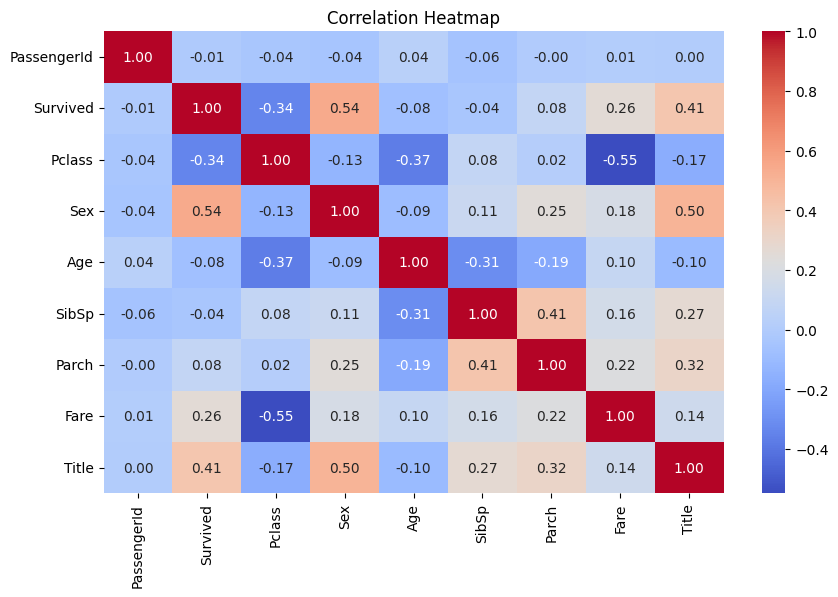

In [12]:
import seaborn as sns

corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2, stratify=y)

print(len(X_train))
print(len(X_test))
print(len(y_train))
print(len(y_test))

712
179
712
179


In [14]:
embarked_mode = X_train['Embarked'].mode()[0]

X_train['Embarked'] = X_train['Embarked'].fillna(embarked_mode)
X_test['Embarked']  = X_test['Embarked'].fillna(embarked_mode)
test_df['Embarked']  = test_df['Embarked'].fillna(embarked_mode)

X_train['Age'] = X_train.groupby(['Sex', 'Pclass'])['Age'].transform(lambda x: x.fillna(x.median()))
X_test['Age']  = X_test.groupby(['Sex', 'Pclass'])['Age'].transform(lambda x: x.fillna(x.median()))
test_df['Age']  = test_df.groupby(['Sex', 'Pclass'])['Age'].transform(lambda x: x.fillna(x.median()))

In [15]:
print(len(X_test))

179


In [16]:
print(X_train['Embarked'].unique())


['S' 'C' 'Q']


In [ ]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# Drop unnecessary columns first
drop_cols = ['Cabin', 'Name', 'Ticket']

X_train = X_train.drop(drop_cols, axis=1)
X_test = X_test.drop(drop_cols, axis=1)
test_df = test_df.drop(drop_cols, axis=1)

ct = ColumnTransformer(
    transformers=[
        ('embarked_ohe', OneHotEncoder(handle_unknown='ignore'), ['Embarked'])
    ],
    remainder='passthrough',
    verbose_feature_names_out=False
)

X_train = ct.fit_transform(X_train)

X_test = ct.transform(X_test)
test_df = ct.transform(test_df)

In [18]:
X_train = pd.DataFrame(
    X_train,
    columns=ct.get_feature_names_out()
)

X_test = pd.DataFrame(
    X_test,
    columns=ct.get_feature_names_out()
)

test_df = pd.DataFrame(
    test_df,
    columns=ct.get_feature_names_out()
)

In [19]:
print(X_train.isna().sum())
print(X_test.isna().sum())
print(X_train.columns)
print(X_test.columns)


Embarked_C     0
Embarked_Q     0
Embarked_S     0
PassengerId    0
Pclass         0
Sex            0
Age            0
SibSp          0
Parch          0
Fare           0
Title          0
dtype: int64
Embarked_C     0
Embarked_Q     0
Embarked_S     0
PassengerId    0
Pclass         0
Sex            0
Age            0
SibSp          0
Parch          0
Fare           0
Title          0
dtype: int64
Index(['Embarked_C', 'Embarked_Q', 'Embarked_S', 'PassengerId', 'Pclass',
       'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Title'],
      dtype='object')
Index(['Embarked_C', 'Embarked_Q', 'Embarked_S', 'PassengerId', 'Pclass',
       'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Title'],
      dtype='object')


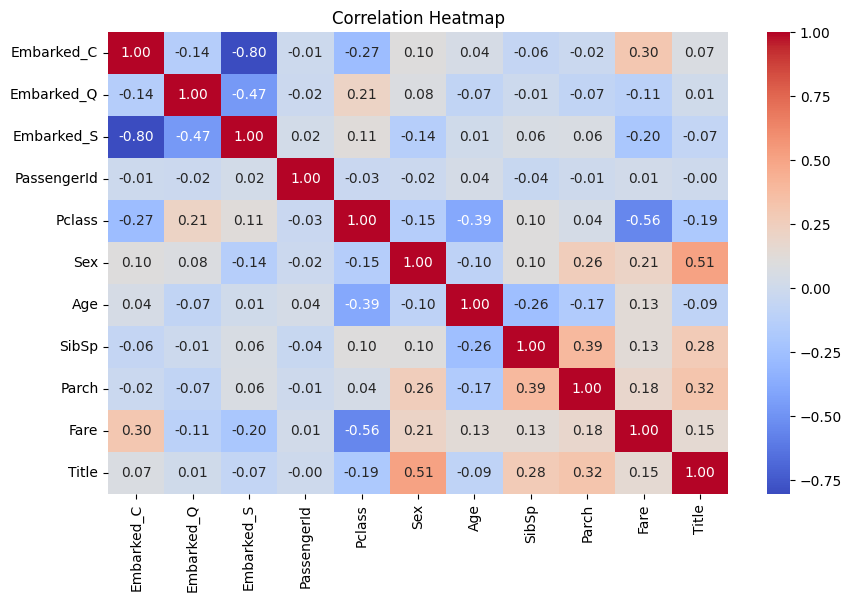

In [20]:
num_cols = ['Embarked_C', 'Embarked_Q', 'Embarked_S', 'Pclass', 'Sex', 'Age',
            'SibSp', 'Parch', 'Fare', 'Title']

for col in num_cols:
    X_train[col] = pd.to_numeric(X_train[col], errors='coerce')

corr = X_train.select_dtypes(include='number').corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [21]:
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [24]:
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('rfc', RandomForestClassifier(random_state=42))
])

In [25]:
param_grid = {
    'rfc__n_estimators': [100, 200],
    'rfc__max_depth': [5, 10, None],
    'rfc__min_samples_split': [2, 5],
    'rfc__min_samples_leaf': [1, 2]
}

In [26]:
rfc_grid = GridSearchCV(pipe, param_grid, cv=5, scoring='f1', n_jobs=-1, verbose=1)
rfc_grid.fit(X_train, y_train)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('rfc',
                                        RandomForestClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'rfc__max_depth': [5, 10, None],
                         'rfc__min_samples_leaf': [1, 2],
                         'rfc__min_samples_split': [2, 5],
                         'rfc__n_estimators': [100, 200]},
             scoring='f1', verbose=1)

In [27]:
print(rfc_grid.best_params_)
print(rfc_grid.best_score_)

{'rfc__max_depth': None, 'rfc__min_samples_leaf': 1, 'rfc__min_samples_split': 5, 'rfc__n_estimators': 200}
0.758000801531532


In [30]:
y_pred = rfc_grid.predict(X_test)

print("Best Params:", rfc_grid.best_params_)

print("Accuracy   :", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

kaggle_pred = rfc_grid.predict(test_df)


Best Params: {'rfc__max_depth': None, 'rfc__min_samples_leaf': 1, 'rfc__min_samples_split': 5, 'rfc__n_estimators': 200}
Accuracy   : 0.8324022346368715
[[100  10]
 [ 20  49]]
              precision    recall  f1-score   support

           0       0.83      0.91      0.87       110
           1       0.83      0.71      0.77        69

    accuracy                           0.83       179
   macro avg       0.83      0.81      0.82       179
weighted avg       0.83      0.83      0.83       179



In [32]:
submission = pd.DataFrame({
    'PassengerId': test_df['PassengerId'],
    'Survived': kaggle_pred
})

submission.to_csv('submission.csv', index=False)

In [22]:
pipe2 = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC())
])

In [23]:
svm_param_grid = {
    'svm__C': [0.1, 1, 10, 100],
    'svm__kernel': ['linear', 'rbf'],
    'svm__gamma': ['scale', 'auto', 0.1, 0.01]
}

In [24]:
svmc_grid = GridSearchCV(pipe2, param_grid=svm_param_grid, cv=5, scoring='f1', n_jobs=-1, verbose=1)
svmc_grid.fit(X_train, y_train)


Fitting 5 folds for each of 32 candidates, totalling 160 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('svm', SVC())]),
             n_jobs=-1,
             param_grid={'svm__C': [0.1, 1, 10, 100],
                         'svm__gamma': ['scale', 'auto', 0.1, 0.01],
                         'svm__kernel': ['linear', 'rbf']},
             scoring='f1', verbose=1)

In [25]:
print(svmc_grid.best_params_)
print(svmc_grid.best_score_)

{'svm__C': 10, 'svm__gamma': 0.01, 'svm__kernel': 'rbf'}
0.7537384345033947


In [26]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred = svmc_grid.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))



Accuracy: 0.8379888268156425
[[98 12]
 [17 52]]
              precision    recall  f1-score   support

           0       0.85      0.89      0.87       110
           1       0.81      0.75      0.78        69

    accuracy                           0.84       179
   macro avg       0.83      0.82      0.83       179
weighted avg       0.84      0.84      0.84       179



In [27]:
test_df['Fare'] = test_df['Fare'].fillna(test_df['Fare'].mean())

In [28]:
test_df.isna().sum()

Embarked_C     0
Embarked_Q     0
Embarked_S     0
PassengerId    0
Pclass         0
Sex            0
Age            0
SibSp          0
Parch          0
Fare           0
Title          0
dtype: int64

In [29]:
kaggle_pred = svmc_grid.predict(test_df)
submission = pd.DataFrame({
    'PassengerId': test_df['PassengerId'],
    'Survived': kaggle_pred
})

In [30]:
submission['PassengerId'] = submission['PassengerId'].astype(int)
submission['Survived'] = submission['Survived'].astype(int)

In [31]:
submission.to_csv('submission.csv', index=False)

In [47]:
from sklearn.neighbors import KNeighborsClassifier

pipe3 = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

knn_param_grid = {
    'knn__n_neighbors': list(range(3, 31, 2)),   
    'knn__weights': ['uniform', 'distance'],
    'knn__metric': ['euclidean', 'manhattan', 'minkowski'],
    'knn__p': [1, 2]
}

In [48]:
knn_grid = GridSearchCV(pipe3, param_grid=knn_param_grid, cv=5, scoring='f1', n_jobs=-1, verbose=1)
knn_grid.fit(X_train, y_train)


Fitting 5 folds for each of 168 candidates, totalling 840 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('knn', KNeighborsClassifier())]),
             n_jobs=-1,
             param_grid={'knn__metric': ['euclidean', 'manhattan', 'minkowski'],
                         'knn__n_neighbors': [3, 5, 7, 9, 11, 13, 15, 17, 19,
                                              21, 23, 25, 27, 29],
                         'knn__p': [1, 2],
                         'knn__weights': ['uniform', 'distance']},
             scoring='f1', verbose=1)

In [49]:
print(knn_grid.best_params_)
print(knn_grid.best_score_)

{'knn__metric': 'euclidean', 'knn__n_neighbors': 11, 'knn__p': 1, 'knn__weights': 'uniform'}
0.7496991869150427


In [51]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred = knn_grid.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8268156424581006
[[98 12]
 [19 50]]
              precision    recall  f1-score   support

           0       0.84      0.89      0.86       110
           1       0.81      0.72      0.76        69

    accuracy                           0.83       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.83      0.83      0.82       179



In [52]:
kaggle_pred = svmc_grid.predict(test_df)
submission = pd.DataFrame({
    'PassengerId': test_df['PassengerId'],
    'Survived': kaggle_pred
})

submission.to_csv('submission_svmc.csv', index=False)